<a href="https://colab.research.google.com/github/aakashkumar089/Class-notes/blob/main/OTS1_Decesion_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("/content/penguins_size.csv")

In [3]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [5]:
df.isna().sum()

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


In [6]:
(10/344) * 100

2.9069767441860463

In [7]:
df= df.dropna()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            334 non-null    object 
 1   island             334 non-null    object 
 2   culmen_length_mm   334 non-null    float64
 3   culmen_depth_mm    334 non-null    float64
 4   flipper_length_mm  334 non-null    float64
 5   body_mass_g        334 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.9+ KB


In [9]:
df['sex'].unique()

array(['MALE', 'FEMALE', '.'], dtype=object)

In [10]:
df['island'].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [11]:
df = df[df['sex'] != '.']

In [12]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [13]:
df['sex'].unique()

array(['MALE', 'FEMALE'], dtype=object)

<Axes: xlabel='culmen_length_mm', ylabel='culmen_depth_mm'>

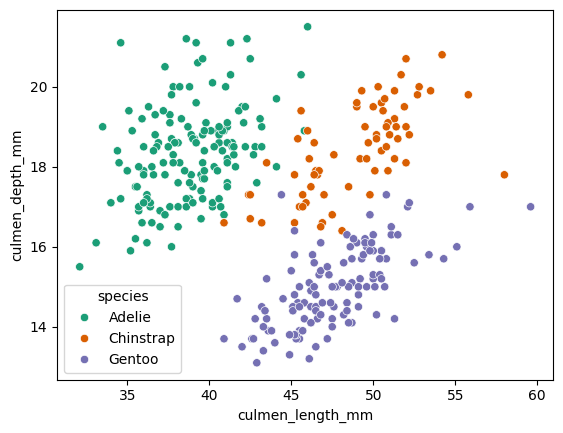

In [14]:
# VIsualisation

sns.scatterplot(x = 'culmen_length_mm' ,y ='culmen_depth_mm', data=df,hue='species',palette='Dark2')

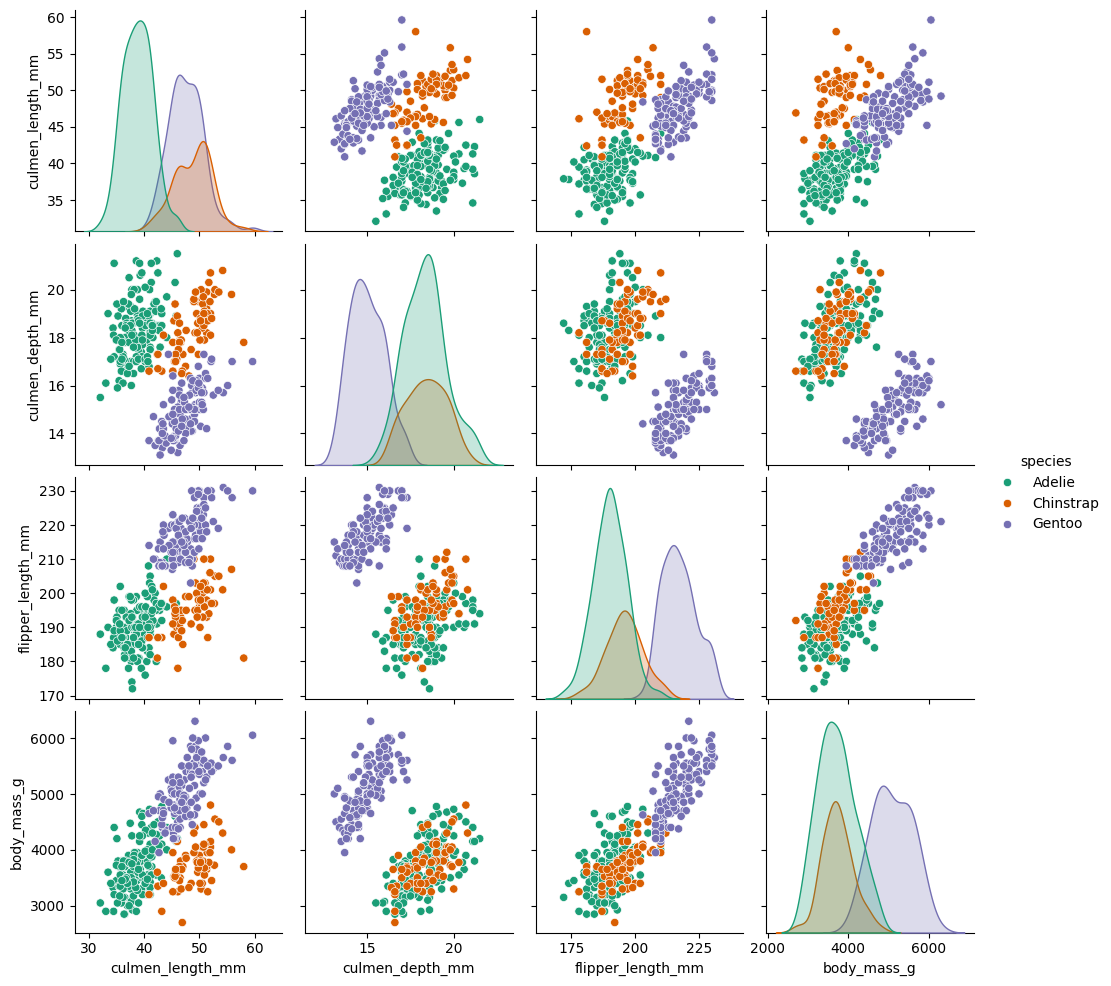

In [15]:
sns.pairplot(df,hue='species',palette='Dark2')

In [16]:
# Feature Engineer

pd.get_dummies(df).astype(int)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
0,39,18,181,3750,1,0,0,0,0,1,0,1
1,39,17,186,3800,1,0,0,0,0,1,1,0
2,40,18,195,3250,1,0,0,0,0,1,1,0
4,36,19,193,3450,1,0,0,0,0,1,1,0
5,39,20,190,3650,1,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
338,47,13,214,4925,0,0,1,1,0,0,1,0
340,46,14,215,4850,0,0,1,1,0,0,1,0
341,50,15,222,5750,0,0,1,1,0,0,0,1
342,45,14,212,5200,0,0,1,1,0,0,1,0


In [17]:
pd.get_dummies(df.drop('species',axis=1), drop_first=True).astype(int)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
0,39,18,181,3750,0,1,1
1,39,17,186,3800,0,1,0
2,40,18,195,3250,0,1,0
4,36,19,193,3450,0,1,0
5,39,20,190,3650,0,1,1
...,...,...,...,...,...,...,...
338,47,13,214,4925,0,0,0
340,46,14,215,4850,0,0,0
341,50,15,222,5750,0,0,1
342,45,14,212,5200,0,0,0


In [18]:
# Train Test Split
X = pd.get_dummies(df.drop('species',axis=1), drop_first=True).astype(int)

y=  df['species']

In [19]:
X.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
0,39,18,181,3750,0,1,1
1,39,17,186,3800,0,1,0
2,40,18,195,3250,0,1,0
4,36,19,193,3450,0,1,0
5,39,20,190,3650,0,1,1


In [20]:
y.head()

,species
0,Adelie
1,Adelie
2,Adelie
4,Adelie
5,Adelie


In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)



In [23]:
X_train

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
27,40,17,187,3200,0,0,0
292,48,15,221,5100,0,0,1
302,47,14,212,4725,0,0,0
62,37,17,185,3600,0,0,0
181,52,20,205,4550,1,0,1
...,...,...,...,...,...,...,...
194,50,19,196,3550,1,0,1
77,37,19,184,3900,0,1,1
112,39,17,193,3200,0,0,0
277,45,15,220,5000,0,0,1


In [24]:
X_test

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
30,39,16,178,3250,1,0,0
317,46,14,222,4875,0,0,0
79,42,19,195,4000,0,1,1
201,49,17,198,3675,1,0,0
63,41,18,192,4050,0,0,1
...,...,...,...,...,...,...,...
20,37,18,174,3400,0,0,0
7,39,19,195,4675,0,1,1
215,55,19,207,4000,1,0,1
99,43,18,192,4100,1,0,1


In [25]:
# Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

In [26]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [27]:
y_pred = model.predict(X_test)

In [28]:
y_pred

array(['Adelie', 'Gentoo', 'Adelie', 'Chinstrap', 'Adelie', 'Gentoo',
       'Gentoo', 'Chinstrap', 'Chinstrap', 'Chinstrap', 'Adelie',
       'Adelie', 'Gentoo', 'Adelie', 'Gentoo', 'Adelie', 'Adelie',
       'Chinstrap', 'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Gentoo',
       'Chinstrap', 'Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Chinstrap',
       'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie', 'Adelie', 'Gentoo',
       'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Chinstrap', 'Chinstrap', 'Adelie', 'Adelie', 'Gentoo',
       'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Gentoo', 'Gentoo',
       'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Chinstrap',
       'Chinstrap', 'Gentoo', 'Gentoo', 'Gentoo', 'Adelie', 'Adelie',
       'Gentoo', 'Adelie', 'Gentoo', 'Adelie', 'Gentoo', 'Adelie',
       'Adelie', 'Gentoo', 'Gentoo', 'Gentoo', 'Chinstrap', 'Adelie',
       'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Gentoo', 'Ge

In [29]:
y_test.shape

(100,)

In [30]:
# Evaluvation
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay

In [31]:
confusion_matrix(y_test,y_pred)

array([[48,  0,  0],
       [ 1, 17,  0],
       [ 0,  0, 34]])

In [32]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      Adelie       0.98      1.00      0.99        48
   Chinstrap       1.00      0.94      0.97        18
      Gentoo       1.00      1.00      1.00        34

    accuracy                           0.99       100
   macro avg       0.99      0.98      0.99       100
weighted avg       0.99      0.99      0.99       100



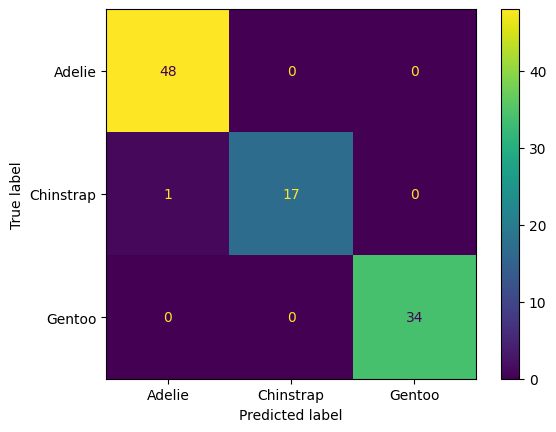

In [33]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.show()

In [34]:
model.feature_importances_

array([0.34840037, 0.07583016, 0.50996668, 0.        , 0.0395539 ,
       0.        , 0.0262489 ])

In [35]:
pd.DataFrame(index=X.columns,data=model.feature_importances_,columns=['Feature Importance'])

,Feature Importance
culmen_length_mm,0.348400
culmen_depth_mm,0.075830
flipper_length_mm,0.509967
body_mass_g,0.000000
island_Dream,0.039554
island_Torgersen,0.000000
sex_MALE,0.026249


In [36]:
#Tree visualisation

from sklearn.tree import plot_tree

In [38]:
ConfusionMatrixDisplay.from_estimator(model,X_train,y_test)

ValueError: Found input variables with inconsistent numbers of samples: [100, 233]

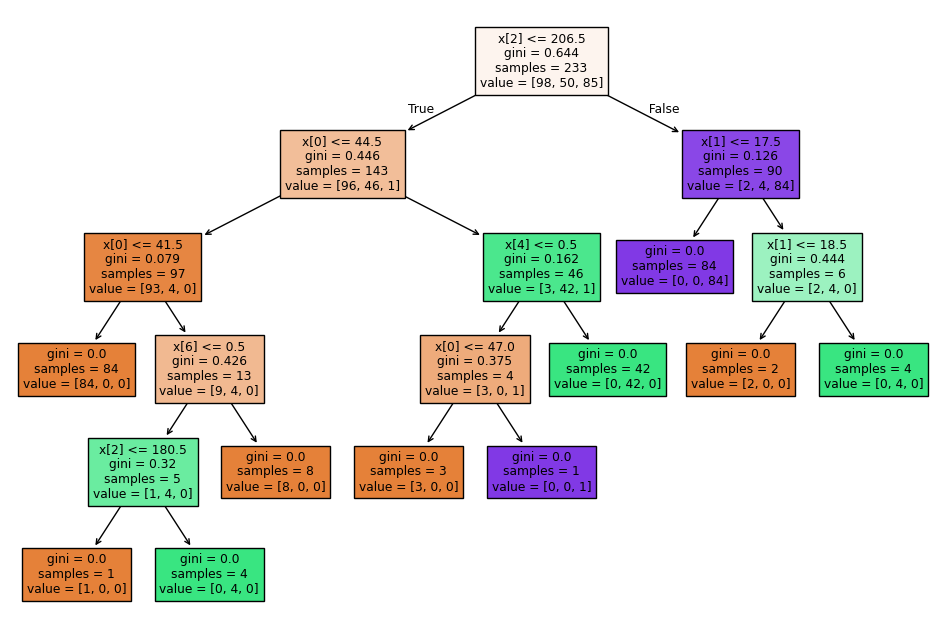

In [39]:
plt.figure(figsize=(12,8))
plot_tree(model,filled=True)
plt.show()

In [40]:
# Check model reports

def report_model(model):
    model_preds = model.predict(X_test)
    print(classification_report(y_test,model_preds))
    print('\n')
    plt.figure(figsize=(12,8), dpi=150)
    plot_tree(model,filled=True,feature_names=X.columns)

              precision    recall  f1-score   support

      Adelie       0.96      1.00      0.98        48
   Chinstrap       1.00      0.89      0.94        18
      Gentoo       1.00      1.00      1.00        34

    accuracy                           0.98       100
   macro avg       0.99      0.96      0.97       100
weighted avg       0.98      0.98      0.98       100





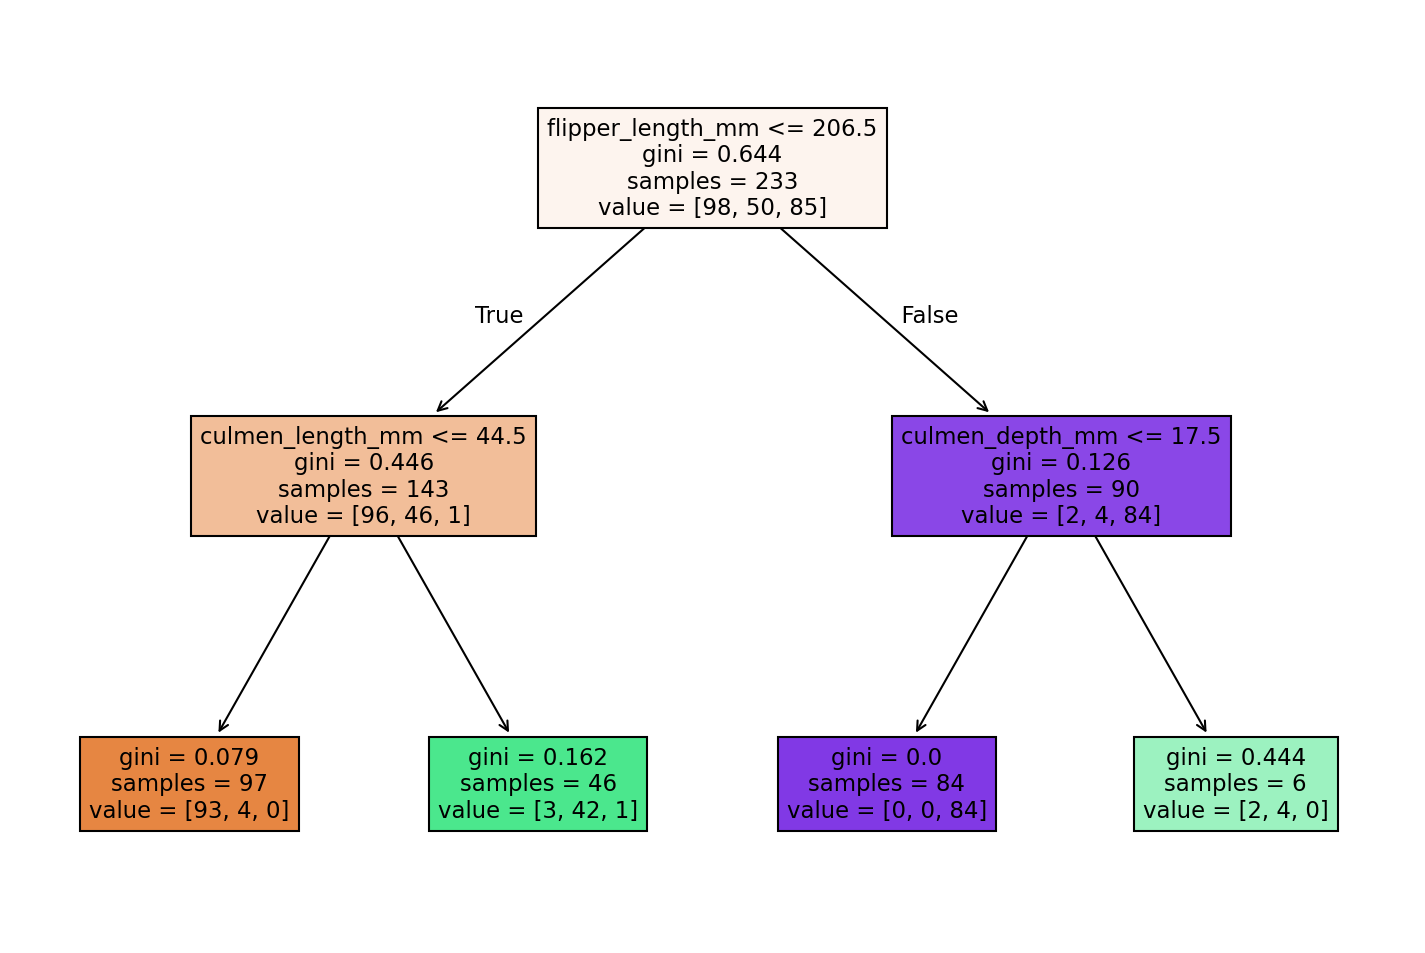

In [41]:
# Using Hypermeter
# Max depth

pruned_tree = DecisionTreeClassifier(max_depth=2)
pruned_tree.fit(X_train,y_train)

report_model(pruned_tree)

              precision    recall  f1-score   support

      Adelie       0.96      1.00      0.98        48
   Chinstrap       1.00      0.89      0.94        18
      Gentoo       1.00      1.00      1.00        34

    accuracy                           0.98       100
   macro avg       0.99      0.96      0.97       100
weighted avg       0.98      0.98      0.98       100





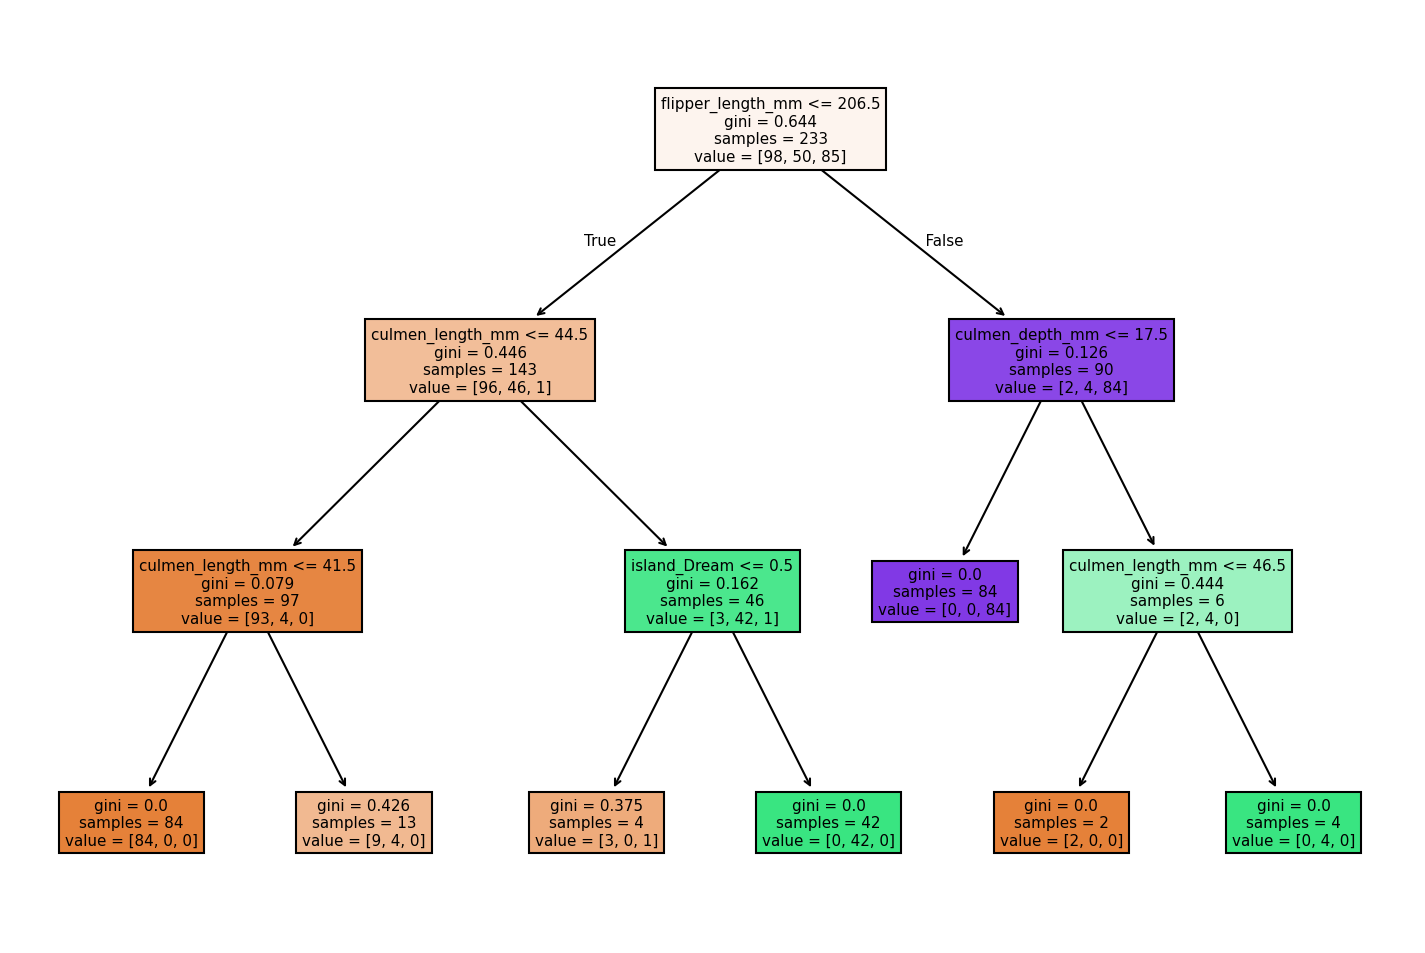

In [42]:
pruned_tree = DecisionTreeClassifier(max_depth=3)
pruned_tree.fit(X_train,y_train)

report_model(pruned_tree)

In [47]:
# Tree score

for d in [2,3,1]:
    model = DecisionTreeClassifier(max_depth=d,random_state=42)
    model.fit(X_train,y_train)
    print(f"Depth = {d} | Train = {model.score(X_train,y_train):.3f} | Test = {model.score(X_test,y_test):.3f}")

Depth = 2 | Train = 0.957 | Test = 0.980
Depth = 3 | Train = 0.979 | Test = 0.980
Depth = 1 | Train = 0.773 | Test = 0.820


# Final prediction for new penguine

## culmen_length_mm
## culmen_depth_mm
## flipper_length_mm
## body_mass_g
## island
## island_Torgersen
## sex

In [50]:
new_data = pd.DataFrame({

'culmen_length_mm':[155],
'culmen_depth_mm':[36],
'flipper_length_mm':[300],
'body_mass_g':[4700],
'sex':['Male'],
})

new_data = pd.get_dummies(new_data,drop_first=True)
new_data = new_data.reindex(columns = X.columns,fill_value=0)
prediction = pruned_tree.predict(new_data)
print(prediction)

['Chinstrap']
